# Customer 360 — Customer Segmentation

This notebook groups customers into meaningful segments based on their behavioral and service-related characteristics. K-Means, Agglomerative Clustering, and DBSCAN are explored and compared, with PCA and anomaly detection used to further understand customer profiles.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest

from sklearn.metrics import silhouette_score,adjusted_rand_score

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import joblib

In [2]:
df = pd.read_csv("../Dataset/customer_360_ml_workshop.csv")

## Customer Segmentation

Segmentation uses:

`TenureMonths`, `MonthlyUsageGB`, `MonthlyChargeEGP`, `NumServices`, `SupportCalls6M`, `LatePayments12M`, and `SatisfactionScore`.

Missing values are median-imputed and all variables are standardized because the clustering methods are distance-based.

In [3]:
seg_cols = [
    "TenureMonths",
    "MonthlyUsageGB",
    "MonthlyChargeEGP",
    "NumServices",
    "SupportCalls6M",
    "LatePayments12M",
    "SatisfactionScore"
]

seg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

z_seg = seg_pipeline.fit_transform(df[seg_cols])
z_seg = pd.DataFrame(z_seg, columns=seg_cols, index=df.index)

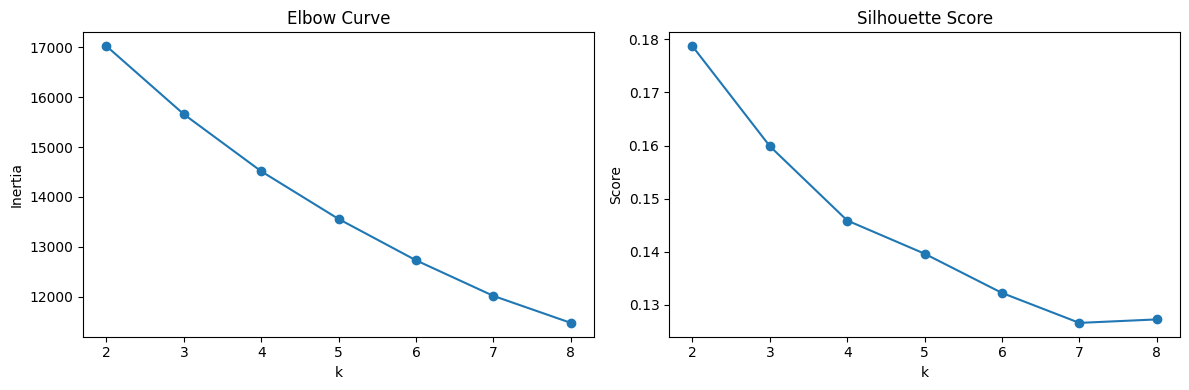

Selected k = 2 using the highest silhouette score.


,Inertia,Silhouette
k,,
2,17022.123,0.179
3,15656.868,0.160
4,14513.831,0.146
5,13557.871,0.140
6,12730.019,0.132
7,12017.109,0.127
8,11476.539,0.127


In [4]:
k_rows = []

for k_value in range(2, 9):
    model = KMeans(n_clusters=k_value, n_init=10, random_state=42)
    labels = model.fit_predict(z_seg)

    k_rows.append({
        "k": k_value,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(z_seg, labels)
    })

k_table = pd.DataFrame(k_rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_table.index, k_table["Inertia"], "o-")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_table.index, k_table["Silhouette"], "o-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

k = int(k_table["Silhouette"].idxmax())
print(f"Selected k = {k} using the highest silhouette score.")
display(k_table.round(3))

In [5]:
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(z_seg)

df["KMeansCluster"] = kmeans_labels

profile = df.groupby("KMeansCluster")[seg_cols].mean()
profile["Customers"] = df["KMeansCluster"].value_counts().sort_index()
profile["ChurnRate"] = df.groupby("KMeansCluster")["Churn"].apply(lambda s: (s == "Yes").mean())
profile["AvgFutureRevenue"] = df.groupby("KMeansCluster")["Future12MRevenueEGP"].mean()

profile.round(2)

,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Customers,ChurnRate,AvgFutureRevenue
KMeansCluster,,,,,,,,,,
0,25.13,243.09,581.44,4.94,2.26,1.11,3.49,1490,0.20,6351.77
1,25.94,217.44,394.50,2.11,2.15,1.11,3.48,1510,0.16,4383.66


In [6]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=seg_cols)

def name_cluster(row):
    if row["SatisfactionScore"] < -0.6 and (row["SupportCalls6M"] > 0.5 or row["LatePayments12M"] > 0.5):
        return "At-Risk Customers"
    if row["TenureMonths"] < -0.5 and row["NumServices"] < -0.3:
        return "New / Low-Engagement"
    if row["MonthlyChargeEGP"] > 0.5 and (row["MonthlyUsageGB"] > 0.4 or row["NumServices"] > 0.4):
        return "High-Value Users"
    if row["LatePayments12M"] > 0.6:
        return "Payment-Risk Customers"
    if row["TenureMonths"] > 0.5 and row["SatisfactionScore"] > 0.3:
        return "Loyal & Engaged"
    return "Steady Core Customers"

cluster_names = {}
used_names = set()

for cluster_id, row in cluster_centers.iterrows():
    proposed = name_cluster(row)

    if proposed in used_names:
        proposed = f"{proposed} ({cluster_id})"

    cluster_names[cluster_id] = proposed
    used_names.add(proposed)

df["Segment"] = df["KMeansCluster"].map(cluster_names)
profile["Segment"] = profile.index.map(cluster_names)

profile.round(2)

,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Customers,ChurnRate,AvgFutureRevenue,Segment
KMeansCluster,,,,,,,,,,,
0,25.13,243.09,581.44,4.94,2.26,1.11,3.49,1490,0.20,6351.77,High-Value Users
1,25.94,217.44,394.50,2.11,2.15,1.11,3.48,1510,0.16,4383.66,Steady Core Customers


### Agglomerative Clustering and DBSCAN

Agglomerative clustering is run with the same selected `k` so its result can be compared with K-Means.

For DBSCAN, label **`-1` means noise**: the customer is not assigned to a sufficiently dense cluster under the selected `eps` and `min_samples`. It does **not** mean fraud or bad behavior.

In [7]:
agg_labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(z_seg)

min_samples = 10

nearest_distances = (NearestNeighbors(n_neighbors=min_samples).fit(z_seg).kneighbors(z_seg)[0][:, -1])

eps = float(np.percentile(nearest_distances, 90))

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(z_seg)

def cluster_silhouette(labels):
    mask = labels != -1
    unique = np.unique(labels[mask])

    if len(unique) < 2:
        return np.nan

    return silhouette_score(z_seg.loc[mask], labels[mask])

comparison = pd.DataFrame({
    "Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(agg_labels)),
        len(set(db_labels)) - (1 if -1 in db_labels else 0)
    ],
    "Noise Points": [
        0,
        0,
        int((db_labels == -1).sum())
    ],
    "Silhouette": [
        silhouette_score(z_seg, kmeans_labels),
        silhouette_score(z_seg, agg_labels),
        cluster_silhouette(db_labels)
    ],
    "ARI vs K-Means": [
        1.0,
        adjusted_rand_score(kmeans_labels, agg_labels),
        adjusted_rand_score(kmeans_labels, db_labels)
    ]
}, index=["K-Means", "Agglomerative", "DBSCAN"])

print(f"DBSCAN eps = {eps:.3f}, min_samples = {min_samples}")
comparison.round(2)

DBSCAN eps = 1.686, min_samples = 10


,Clusters,Noise Points,Silhouette,ARI vs K-Means
K-Means,2,0,0.18,1.0
Agglomerative,2,0,0.11,0.3
DBSCAN,1,70,NaN,0.0


### Segmentation Interpretation

A high silhouette score is useful evidence of separation, but it is not enough by itself. A business-useful segment should also be interpretable, sufficiently large, reasonably stable, and connected to meaningful customer behavior or value.

The cluster profile table above should be used to describe the practical differences between segments.

## F. PCA & Anomaly Detection

Explained variance ratio: [0.26 0.15]
PC1 + PC2 explain 41.2% of the variance.


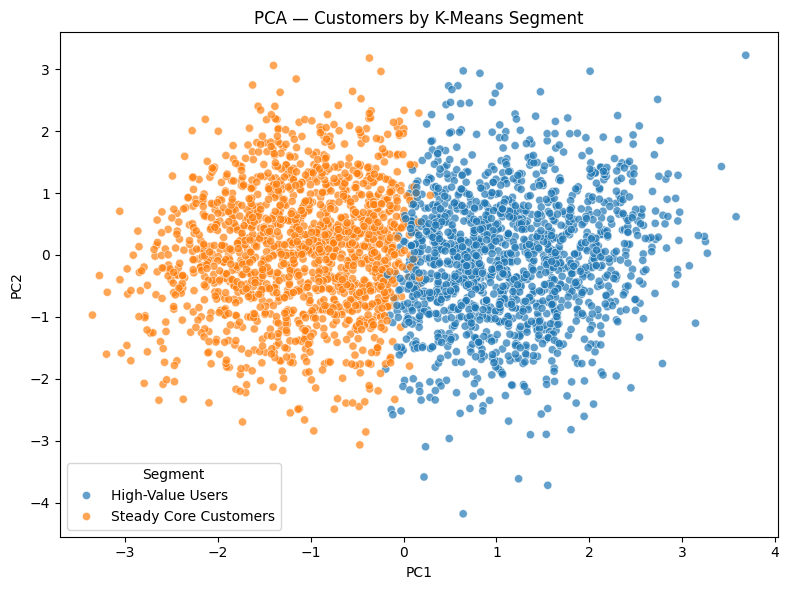

,PC1,PC2
TenureMonths,-0.02,-0.02
MonthlyUsageGB,0.22,0.59
MonthlyChargeEGP,0.71,-0.00
NumServices,0.67,-0.21
SupportCalls6M,0.03,0.32
LatePayments12M,0.01,-0.55
SatisfactionScore,0.02,0.44


In [8]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(z_seg)

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(2))
print(f"PC1 + PC2 explain {pca.explained_variance_ratio_.sum():.1%} of the variance.")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PC1", y="PC2",hue="Segment", alpha=0.7, s=35)
plt.title("PCA — Customers by K-Means Segment")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=seg_cols,
    columns=["PC1", "PC2"]
)

loadings.round(2)

In [9]:
iso = IsolationForest(contamination=0.03,random_state=42)

df["AnomalyFlag"] = (iso.fit_predict(z_seg) == -1).astype(int)
df["AnomalyScore"] = iso.decision_function(z_seg)

z_df = pd.DataFrame(z_seg, columns=seg_cols, index=df.index)

def anomaly_reason(index):
    values = z_df.loc[index].abs().sort_values(ascending=False).head(2)

    return "; ".join(f"{'high' if z_df.loc[index, col] > 0 else 'low'} {col}"for col in values.index)

anomalies = df[df["AnomalyFlag"] == 1].copy()
anomalies["WhyUnusual"] = [
    anomaly_reason(i) for i in anomalies.index
]

anomalies = anomalies.sort_values("AnomalyScore").head(10)

print(f"Isolation Forest flagged {df['AnomalyFlag'].sum()} customers ({df['AnomalyFlag'].mean():.1%}).")

display(
    anomalies[
        [
            "CustomerID", "Segment", "TenureMonths",
            "MonthlyUsageGB", "MonthlyChargeEGP",
            "SupportCalls6M", "LatePayments12M",
            "SatisfactionScore", "AnomalyScore",
            "WhyUnusual"
        ]
    ]
)

print("An anomaly is an unusual customer profile. It is not automatically fraud.")

Isolation Forest flagged 90 customers (3.0%).


,CustomerID,Segment,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,SupportCalls6M,LatePayments12M,SatisfactionScore,AnomalyScore,WhyUnusual
2045,CUST-02046,High-Value Users,16,443.6,743.84,0,4,5.0,-0.070543,high LatePayments12M; high MonthlyUsageGB
1311,CUST-01312,Steady Core Customers,56,69.4,231.29,1,0,1.0,-0.069434,low SatisfactionScore; low MonthlyChargeEGP
1948,CUST-01949,Steady Core Customers,46,95.5,292.09,6,3,5.0,-0.062481,high SupportCalls6M; high LatePayments12M
1288,CUST-01289,High-Value Users,72,286.0,485.50,5,5,3.0,-0.057637,high LatePayments12M; high TenureMonths
1316,CUST-01317,High-Value Users,56,133.0,552.62,6,0,1.0,-0.052570,high SupportCalls6M; low SatisfactionScore
965,CUST-00966,High-Value Users,6,325.6,748.06,0,0,1.0,-0.050205,low SatisfactionScore; high MonthlyChargeEGP
1541,CUST-01542,Steady Core Customers,42,125.9,319.34,5,5,3.0,-0.046042,high LatePayments12M; high SupportCalls6M
460,CUST-00461,Steady Core Customers,24,251.9,325.84,8,0,1.0,-0.044682,high SupportCalls6M; low SatisfactionScore
995,CUST-00996,High-Value Users,10,178.4,629.68,6,5,3.0,-0.043806,high LatePayments12M; high SupportCalls6M
913,CUST-00914,Steady Core Customers,37,221.6,456.92,0,4,1.0,-0.041721,high LatePayments12M; low SatisfactionScore


An anomaly is an unusual customer profile. It is not automatically fraud.


In [10]:
joblib.dump(kmeans, "../models/segmentation_model.pkl")

['../models/segmentation_model.pkl']